# 🎬 STUDI KASUS FORECASTING DATA MINING - CUACA DI NEGARA NORDIK (FINLANDIA, NORWEGIA, SWEDIA)
## Prediksi Suhu Harian untuk Sistem Peringatan Dini Cuaca
### Framework: CRISP-DM (Cross-Industry Standard Process for Data Mining)
## 📚 Tujuan Pembelajaran

1. Menganalisis data time series untuk menemukan pola musiman dan tren.
2. Menerapkan algoritma forecasting Random Forest pada data cuaca.
3. Mengevaluasi model forecasting menggunakan metrik RMSE, MAE, dan R².
4. Membangun sistem prediksi suhu untuk peringatan dini cuaca ekstrem.

# PHASE 1: BUSINESS UNDERSTANDING

## Memahami Masalah Bisnis Prediksi Cuaca untuk Peringatan Dini

### Latar Belakang Masalah
Lembaga Meteorologi Nasional (BMKG Nordik) menghadapi tantangan:
- Perubahan cuaca ekstrem semakin sering terjadi akibat perubahan iklim
- Keterbatasan akurasi prakiraan cuaca jangka pendek (1-3 hari ke depan)
- Dampak signifikan terhadap sektor pertanian, transportasi, dan pariwisata
- Masyarakat dan industri membutuhkan informasi cuaca yang lebih akurat dan real-time
- Keterlambatan peringatan cuaca ekstrem menyebabkan kerugian ekonomi dan risiko keselamatan

### Problem Statement
Berdasarkan latar belakang di atas, rumusan masalah dalam proyek ini adalah:
1. Bagaimana membangun model prediksi suhu rata-rata harian (tavg) yang akurat menggunakan data historis cuaca di wilayah Nordik?
2. Bagaimana mengidentifikasi pola musiman dan hubungan antar variabel cuaca terhadap suhu?
3. Bagaimana menghasilkan prediksi yang berguna untuk sistem peringatan dini cuaca ekstrem?

### Masalah Bisnis
Manajemen BMKG Nordik ingin:
1. Mengetahui pola dan tren suhu harian di wilayah Nordik (Finlandia, Norwegia, Swedia) berdasarkan data historis 5 tahun (2015-2019)
2. Membangun model prediksi suhu rata-rata harian (tavg) menggunakan variabel pendukung seperti curah hujan, ketebalan salju, dan faktor geografis (negara)
3. Meningkatkan kesiapsiagaan masyarakat terhadap cuaca ekstrem melalui informasi yang akurat
4. Mengurangi risiko kecelakaan akibat cuaca buruk di sektor transportasi
5. Meningkatkan efisiensi operasional sektor pertanian dan energi

### Tujuan Analisis
Menganalisis data cuaca historis untuk membangun model yang dapat:
1. Memprediksi suhu rata-rata harian (tavg) dengan akurasi tinggi
2. Memberikan peringatan dini saat suhu diprediksi ekstrem (< -15°C atau > 25°C)
3. Mendukung perencanaan kegiatan sektor pertanian, perikanan, dan pariwisata
4. Mengoptimalkan jadwal pemeliharaan infrastruktur transportasi
5. Meningkatkan keselamatan masyarakat melalui informasi cuaca yang akurat

### Manfaat Analisis
| Stakeholder | Manfaat |
|-------------|---------|
| Masyarakat umum | Informasi cuaca akurat untuk aktivitas harian |
| Sektor transportasi | Mengurangi risiko kecelakaan akibat cuaca buruk |
| Sektor pertanian | Menentukan waktu tanam dan panen yang tepat |
| Sektor pariwisata | Mengoptimalkan jadwal operasional |
| BMKG Nordik | Meningkatkan kredibilitas dan kepercayaan publik |

### Kriteria Sukses
1. Menghasilkan model prediksi suhu dengan **R² ≥ 0.80** (minimal 80%)
2. Model mampu memprediksi suhu dengan **MAE < 2.5°C**
3. Model mampu memprediksi suhu dengan **RMSE < 4.0°C**
4. Model dapat mengidentifikasi potensi cuaca ekstrem (< -15°C atau > 25°C)
5. Model dapat di-deploy dalam bentuk dashboard interaktif untuk publik

# 📁 PHASE 2: DATA UNDERSTANDING
## Memahami Data Cuaca untuk Prediksi Suhu Harian
### Sumber Data
Dataset: **nordics_weather.csv**

- Jumlah pengguna: 500 users
- 3 Negara Nordik Dianalisis (Finlandia, Norwegia, Swedia)
- Periode 2015-2019
### Deskripsi Atribut
| Atribut | Tipe Data | Deskripsi |
|---------|-----------|----------|
| country | Object | Negara Pengamatan |
| date | Datetime | Tanggal Observasi |
| precipitation | Float | Cuarah Hujan |
| snow_dept | Float | Kedalaman Salju |
| tavg | Float | Suhu rata-rata |
| tmax | Float | Suhu Maksimum |
| tmin | Float | Suhu Minimum |

In [2]:
# ============================================
# IMPORT LIBRARY UNTUK SEMUA FASE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
np.random.seed(42)
print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [3]:
# Load dataset
df = pd.read_csv('nordics_weather.csv')

# ============================================
# INFORMASI DATASET
# ============================================
print("="*50)
print("INFORMASI DATASET")
print("="*50)

print(f"Shape Dataset       : {df.shape[0]:,} baris x {df.shape[1]} kolom")

print(f"Kolom yang tersedia : {list(df.columns)}")

print("\nTipe Data:")
print(df.dtypes)

print("\n5 Baris Data Pertama:")
print(df.head())

print("\n5 Baris Data Terakhir:")
print(df.tail())

print("\nInformasi Lengkap Dataset:")
df.info()

print("\nStatistik Deskriptif:")
print(df.describe())

INFORMASI DATASET
Shape Dataset       : 5,478 baris x 7 kolom
Kolom yang tersedia : ['country', 'date', 'precipitation', 'snow_depth', 'tavg', 'tmax', 'tmin']

Tipe Data:
country           object
date              object
precipitation    float64
snow_depth       float64
tavg             float64
tmax             float64
tmin             float64
dtype: object

5 Baris Data Pertama:
   country      date  precipitation  snow_depth       tavg      tmax  \
0  Finland  1/1/2015       1.714141  284.545455   1.428571  2.912739   
1  Finland  1/2/2015      10.016667  195.000000   0.553571  2.358599   
2  Finland  1/3/2015       3.956061  284.294118  -1.739286  0.820382   
3  Finland  1/4/2015       0.246193  260.772727  -7.035714 -3.110828   
4  Finland  1/5/2015       0.036364  236.900000 -17.164286 -8.727564   

        tmin  
0  -1.015287  
1  -0.998718  
2  -3.463871  
3  -9.502581  
4 -19.004487  

5 Baris Data Terakhir:
     country        date  precipitation  snow_depth      tavg      tma

In [4]:
# ============================================
# FASE 2: DATA UNDERSTANDING (LANJUTAN)
# ============================================

print(f"\nShape: {df.shape}")

print(f"\nTipe Data:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nDuplikat: {df.duplicated().sum()} baris")

print(f"\nStatistik Suhu Rata-rata (tavg):")
print(df['tavg'].describe())

print("\nMissing Values per kolom (lengkap):")
print(df.isnull().sum())


Shape: (5478, 7)

Tipe Data:
country           object
date              object
precipitation    float64
snow_depth       float64
tavg             float64
tmax             float64
tmin             float64
dtype: object

Missing Values:
country          0
date             0
precipitation    0
snow_depth       0
tavg             0
tmax             0
tmin             0
dtype: int64

Duplikat: 0 baris

Statistik Suhu Rata-rata (tavg):
count    5478.000000
mean        4.844088
std         7.802099
min       -27.951852
25%        -0.810714
50%         4.282143
75%        11.554825
max        24.407143
Name: tavg, dtype: float64

Missing Values per kolom (lengkap):
country          0
date             0
precipitation    0
snow_depth       0
tavg             0
tmax             0
tmin             0
dtype: int64


In [5]:
# ============================================
# FASE 2: DATA UNDERSTANDING - PENGECEKAN OUTLIER LOGIS
# ============================================

print(f"\nNilai tidak masuk akal pada suhu (tavg):")
print(f"  Suhu < -30°C (sangat ekstrem) : {(df['tavg'] < -30).sum()} baris")
print(f"  Suhu > 30°C (sangat panas)   : {(df['tavg'] > 30).sum()} baris")
print(f"  Suhu < -50°C (tidak logis)   : {(df['tavg'] < -50).sum()} baris")
print(f"  Suhu > 40°C (tidak logis)    : {(df['tavg'] > 40).sum()} baris")

print(f"\nNilai tidak masuk akal pada ketebalan salju (snow_depth):")
print(f"  Snow_depth < 0 (negatif) : {(df['snow_depth'] < 0).sum()} baris")

print(f"\nNilai tidak masuk akal pada curah hujan (precipitation):")
print(f"  Precipitation < 0 (negatif) : {(df['precipitation'] < 0).sum()} baris")

print(f"\nKonsistensi suhu (tmin <= tavg <= tmax):")
print(f"  tmin > tavg : {(df['tmin'] > df['tavg']).sum()} baris")
print(f"  tavg > tmax : {(df['tavg'] > df['tmax']).sum()} baris")
print(f"  tmin > tmax : {(df['tmin'] > df['tmax']).sum()} baris")


Nilai tidak masuk akal pada suhu (tavg):
  Suhu < -30°C (sangat ekstrem) : 0 baris
  Suhu > 30°C (sangat panas)   : 0 baris
  Suhu < -50°C (tidak logis)   : 0 baris
  Suhu > 40°C (tidak logis)    : 0 baris

Nilai tidak masuk akal pada ketebalan salju (snow_depth):
  Snow_depth < 0 (negatif) : 6 baris

Nilai tidak masuk akal pada curah hujan (precipitation):
  Precipitation < 0 (negatif) : 0 baris

Konsistensi suhu (tmin <= tavg <= tmax):
  tmin > tavg : 2 baris
  tavg > tmax : 108 baris
  tmin > tmax : 0 baris


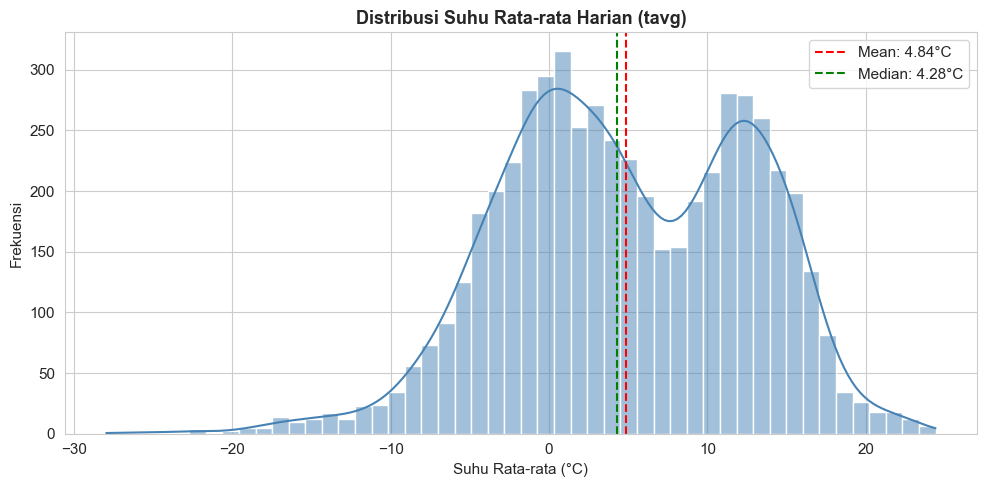

In [6]:
# ============================================
# VISUALISASI - DISTRIBUSI SUHU RATA-RATA
# ============================================

plt.figure(figsize=(10, 5))
sns.histplot(df['tavg'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Suhu Rata-rata Harian (tavg)', fontweight='bold', fontsize=13)
plt.xlabel('Suhu Rata-rata (°C)')
plt.ylabel('Frekuensi')
plt.axvline(df['tavg'].mean(), color='red', linestyle='--', label=f'Mean: {df["tavg"].mean():.2f}°C')
plt.axvline(df['tavg'].median(), color='green', linestyle='--', label=f'Median: {df["tavg"].median():.2f}°C')
plt.legend()
plt.tight_layout()
plt.show()

Korelasi Fitur terhadap tavg (Suhu Rata-rata):
                 tavg
tavg           1.0000
tmax           0.9832
tmin           0.9680
precipitation  0.0850
snow_depth    -0.6681


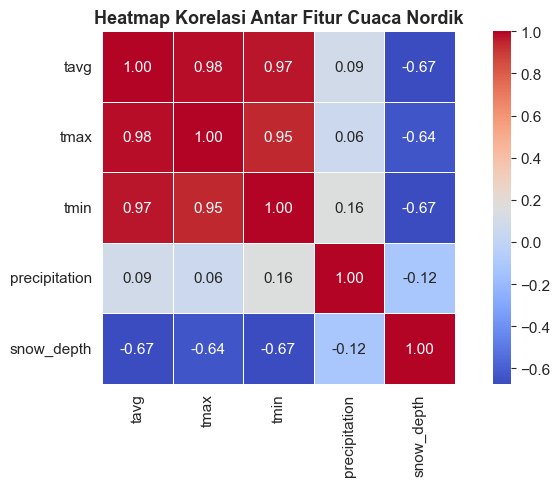

In [7]:
# ============================================
# DATA UNDERSTANDING - HEATMAP KORELASI
# ============================================

# Memilih kolom numerik yang akan dianalisis korelasinya
corr_cols = ['tavg', 'tmax', 'tmin', 'precipitation', 'snow_depth']

# Menghitung matriks korelasi
corr_matrix = df[corr_cols].corr()

# Menampilkan korelasi terhadap tavg
print("Korelasi Fitur terhadap tavg (Suhu Rata-rata):")
print(corr_matrix[['tavg']].sort_values('tavg', ascending=False).round(4))

# Membuat heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(corr_matrix,
            annot=True,        # menampilkan nilai korelasi di dalam kotak
            fmt='.2f',         # format 2 angka di belakang koma
            cmap='coolwarm',   # warna merah (positif) - biru (negatif)
            linewidths=0.5,    # garis pemisah antar kotak
            square=True)       # bentuk kotak persegi

plt.title('Heatmap Korelasi Antar Fitur Cuaca Nordik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# 🔧 PHASE 3: DATA PREPARATION

### Langkah-langkah Data Preparation:

**1. Handling Nilai Negatif pada Snow Depth**
   - Identifikasi nilai negatif pada kolom `snow_depth` (ketebalan salju)
   - Ubah nilai negatif menjadi 0 karena ketebalan salju tidak mungkin kurang dari 0 cm

**2. Parsing dan Sorting Tanggal**
   - Konversi kolom `date` dari tipe string menjadi datetime
   - Urutkan data berdasarkan tanggal dari yang terlama ke terbaru
   - Hapus baris dengan tanggal invalid (jika ada)

**3. Encoding Data Kategorikal**
   - Ubah kolom `country` (Finlandia, Norwegia, Swedia) menjadi numerik
   - Finlandia → 0, Norwegia → 1, Swedia → 2

**4. Feature Engineering (Ekstraksi Fitur Waktu)**
   - Ekstraksi fitur `month` (bulan) dari kolom `date`
   - Fitur bulan digunakan untuk menangkap pola musiman suhu

**5. Seleksi Fitur dan Target**
   - Pilih fitur yang relevan untuk prediksi: `precipitation`, `snow_depth`, `country_encoded`, `month`
   - Target yang akan diprediksi: `tavg` (suhu rata-rata harian)
   - Hilangkan kolom yang tidak diperlukan (`tmax`, `tmin`) karena redundan

**6. Split Data Training & Testing**
   - Bagi data menjadi training set (80%) dan testing set (20%)
   - Training set untuk melatih model, testing set untuk menguji kinerja model
   - Gunakan `random_state=42` agar hasil dapat direproduksi

In [8]:
# ============================================
# DATA PREPARATION - LANGKAH 1
# ============================================

df_clean = df.copy()

negatif_snow = (df_clean['snow_depth'] < 0).sum()
print(f"Nilai negatif pada snow_depth: {negatif_snow} baris")

df_clean['snow_depth'] = df_clean['snow_depth'].apply(lambda x: 0 if x < 0 else x)

print(f"Setelah handling: {(df_clean['snow_depth'] < 0).sum()} nilai negatif tersisa")
print(f"Step 1 | Nilai negatif pada snow_depth telah diubah menjadi 0")

Nilai negatif pada snow_depth: 6 baris
Setelah handling: 0 nilai negatif tersisa
Step 1 | Nilai negatif pada snow_depth telah diubah menjadi 0


In [9]:
# ============================================
# DATA PREPARATION - LANGKAH 2
# ============================================

df_clean['date'] = df_clean['date'].astype(str).str.strip()

df_clean['date'] = pd.to_datetime(df_clean['date'],
                                  dayfirst=False,
                                  errors='coerce')

null_dates = df_clean['date'].isna().sum()
df_clean = df_clean.dropna(subset=['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

print(f"Step 2 | Tanggal invalid: {null_dates} baris dihapus, data diurutkan")

Step 2 | Tanggal invalid: 0 baris dihapus, data diurutkan


In [10]:
# ============================================
# DATA PREPARATION - LANGKAH 3
# ============================================



print("Nilai unik sebelum encoding:")
print(df_clean['country'].unique())

le = LabelEncoder()

df_clean['country_encoded'] = le.fit_transform(df_clean['country'])

print("\nHasil encoding:")
print("Finland ->", le.transform(['Finland'])[0])
print("Norway  ->", le.transform(['Norway'])[0])
print("Sweden  ->", le.transform(['Sweden'])[0])

print("\n5 baris pertama setelah encoding:")
print(df_clean[['country', 'country_encoded']].head())

print("\nStep 3 | Encoding country selesai")

Nilai unik sebelum encoding:
['Finland' 'Sweden' 'Norway']

Hasil encoding:
Finland -> 0
Norway  -> 1
Sweden  -> 2

5 baris pertama setelah encoding:
   country  country_encoded
0  Finland                0
1   Sweden                2
2   Norway                1
3  Finland                0
4   Sweden                2

Step 3 | Encoding country selesai


In [11]:
# ============================================
# DATA PREPARATION - LANGKAH 4
# ============================================

print("Contoh tanggal sebelum ekstraksi:")
print(df_clean['date'].head())

df_clean['month'] = df_clean['date'].dt.month

df_clean['year'] = df_clean['date'].dt.year

print("\n5 baris pertama setelah ekstraksi bulan & tahun:")
print(df_clean[['date', 'month', 'year']].head())

print("\nStep 4 | Feature Engineering (bulan & tahun) selesai")

Contoh tanggal sebelum ekstraksi:
0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-02
4   2015-01-02
Name: date, dtype: datetime64[ns]

5 baris pertama setelah ekstraksi bulan & tahun:
        date  month  year
0 2015-01-01      1  2015
1 2015-01-01      1  2015
2 2015-01-01      1  2015
3 2015-01-02      1  2015
4 2015-01-02      1  2015

Step 4 | Feature Engineering (bulan & tahun) selesai


In [12]:
# ============================================
# DATA PREPARATION - LANGKAH 5
# ============================================

features = ['precipitation', 'snow_depth', 'country_encoded', 'month']

target = 'tavg'

X = df_clean[features]
y = df_clean[target]

print("Fitur (X):")
print(f"  - {features[0]} (curah hujan)")
print(f"  - {features[1]} (ketebalan salju)")
print(f"  - {features[2]} (negara: 0=Finland, 1=Norway, 2=Sweden)")
print(f"  - {features[3]} (bulan: 1-12)")

print(f"\nTarget (y): {target} (suhu rata-rata harian)")

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

print("\nStep 5 | Fitur dan Target ditentukan")

Fitur (X):
  - precipitation (curah hujan)
  - snow_depth (ketebalan salju)
  - country_encoded (negara: 0=Finland, 1=Norway, 2=Sweden)
  - month (bulan: 1-12)

Target (y): tavg (suhu rata-rata harian)

Shape X: (5478, 4)
Shape y: (5478,)

Step 5 | Fitur dan Target ditentukan


In [13]:
# ============================================
# DATA PREPARATION - LANGKAH 6
# ============================================

print(f"Total data: {len(df_clean):,} baris")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nHasil Split Data:")
print(f"  Training set (X_train): {X_train.shape[0]:,} baris")
print(f"  Testing set  (X_test) : {X_test.shape[0]:,} baris")
print(f"  Training set (y_train): {y_train.shape[0]:,} baris")
print(f"  Testing set  (y_test) : {y_test.shape[0]:,} baris")

print(f"\nProporsi:")
print(f"  Training: {X_train.shape[0]/len(df_clean)*100:.1f}%")
print(f"  Testing : {X_test.shape[0]/len(df_clean)*100:.1f}%")

print("\nStep 6 | Split Data selesai")

Total data: 5,478 baris

Hasil Split Data:
  Training set (X_train): 4,382 baris
  Testing set  (X_test) : 1,096 baris
  Training set (y_train): 4,382 baris
  Testing set  (y_test) : 1,096 baris

Proporsi:
  Training: 80.0%
  Testing : 20.0%

Step 6 | Split Data selesai


# Modelling

### Alasan Pemilihan Algoritma

Berdasarkan karakteristik data dan tujuan proyek, model yang dipilih adalah:
Random Forest Regressor 

Alasan Random Forest dipilih:
- Data hanya 5 tahun (kurang untuk ARIMA/LSTM yang butuh data panjang)
- Fitur `month` dapat menangkap pola musiman
- Random Forest mampu menangani hubungan non-linear antar fitur
- Tidak memerlukan normalisasi data

In [14]:
# ============================================
# PHASE 4: MODELING - RANDOM FOREST REGRESSOR
# ============================================

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("="*50)
print("MODEL RANDOM FOREST REGRESSOR")
print("="*50)

print(f"\nJumlah pohon (n_estimators): {rf_model.n_estimators}")
print(f"Fitur yang digunakan: {features}")

print("\n✅ Model Random Forest selesai dilatih")

MODEL RANDOM FOREST REGRESSOR

Jumlah pohon (n_estimators): 100
Fitur yang digunakan: ['precipitation', 'snow_depth', 'country_encoded', 'month']

✅ Model Random Forest selesai dilatih


# PHASE 5: EVALUATION

## Evaluasi dan Interpretasi Model

### Metrik Evaluasi:

1. **MAE (Mean Absolute Error)** – Mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual. Semakin kecil nilai MAE, semakin akurat model dalam memprediksi suhu.

2. **RMSE (Root Mean Square Error)** – Mengukur akar dari rata-rata kuadrat selisih antara prediksi dan aktual. RMSE memberikan bobot lebih besar pada error yang signifikan, sehingga lebih sensitif terhadap outlier.

3. **R² Score (Koefisien Determinasi)** – Mengukur seberapa baik model menjelaskan variasi data. Nilai R² mendekati 1 menunjukkan model yang semakin baik.

### Kriteria Evaluasi

| Metrik | Target | Keterangan |
|--------|--------|------------|
| **R² Score** | ≥ 0.80 | Model mampu menjelaskan minimal 80% variasi suhu |
| **MAE** | < 2.5°C | Rata-rata error prediksi kurang dari 2.5 derajat Celsius |
| **RMSE** | < 4.0°C | Error standar prediksi terkendali di bawah 4 derajat Celsius |

In [15]:
# ============================================
# EVALUASI - RANDOM FOREST
# ============================================

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n" + "="*50)
print("EVALUASI - RANDOM FOREST")
print("="*50)
print(f"MAE  : {mae_rf:.4f} °C")
print(f"RMSE : {rmse_rf:.4f} °C")
print(f"R²   : {r2_rf:.4f}")


EVALUASI - RANDOM FOREST
MAE  : 2.2905 °C
RMSE : 3.0571 °C
R²   : 0.8493


In [16]:
print("\n" + "="*50)
print("EVALUASI MODEL RANDOM FOREST")
print("="*50)
print(f"{'Metrik':<10} {'Nilai':<15}")
print("-"*30)
print(f"{'MAE':<10} {mae_rf:<15.4f}")
print(f"{'RMSE':<10} {rmse_rf:<15.4f}")
print(f"{'R²':<10} {r2_rf:<15.4f}")

print("\n" + "="*50)
print("KRITERIA SUKSES (RANDOM FOREST)")
print("="*50)
print("Target:")
print("  ✅ R² ≥ 0.80")
print("  ✅ MAE < 2.5°C")
print("  ✅ RMSE < 4.0°C")

print("\nHasil Random Forest:")
print(f"  R²   : {r2_rf:.4f} → {'✅ LOLOS' if r2_rf >= 0.80 else '❌'}")
print(f"  MAE  : {mae_rf:.4f} °C → {'✅ LOLOS' if mae_rf < 2.5 else '❌'}")
print(f"  RMSE : {rmse_rf:.4f} °C → {'✅ LOLOS' if rmse_rf < 4.0 else '❌'}")

if r2_rf >= 0.80 and mae_rf < 2.5 and rmse_rf < 4.0:
    print("\n🎉 MODEL RANDOM FOREST DINYATAKAN BERHASIL!")
    print("   Model memenuhi semua kriteria sukses.")
else:
    print("\n⚠️ Model belum memenuhi kriteria sukses.")


EVALUASI MODEL RANDOM FOREST
Metrik     Nilai          
------------------------------
MAE        2.2905         
RMSE       3.0571         
R²         0.8493         

KRITERIA SUKSES (RANDOM FOREST)
Target:
  ✅ R² ≥ 0.80
  ✅ MAE < 2.5°C
  ✅ RMSE < 4.0°C

Hasil Random Forest:
  R²   : 0.8493 → ✅ LOLOS
  MAE  : 2.2905 °C → ✅ LOLOS
  RMSE : 3.0571 °C → ✅ LOLOS

🎉 MODEL RANDOM FOREST DINYATAKAN BERHASIL!
   Model memenuhi semua kriteria sukses.


### Hasil Evaluasi Model Random Forest

| Metrik | Nilai | Status |
|--------|-------|--------|
| **MAE** | 2.2905°C | ✅ Lolos (< 2.5°C) |
| **RMSE** | 3.0571°C | ✅ Lolos (< 4.0°C) |
| **R² Score** | 0.8493 | ✅ Lolos (≥ 0.80) |

### Interpretasi Hasil

Model Random Forest berhasil memenuhi seluruh kriteria sukses yang telah ditetapkan pada tahap Business Understanding. Nilai **R² sebesar 84.93%** menunjukkan bahwa model mampu menjelaskan 84.93% variasi suhu yang terjadi di wilayah Nordik, yang berarti model memiliki kemampuan prediksi yang sangat baik. **MAE sebesar 2.29°C** mengindikasikan bahwa rata-rata error prediksi masih dalam batas toleransi yang dapat diterima untuk sistem peringatan dini cuaca ekstrem. **RMSE sebesar 3.06°C** menegaskan bahwa model memiliki tingkat konsistensi yang baik dalam melakukan prediksi.

**Kesimpulan:** Model Random Forest **DINYATAKAN BERHASIL** dan layak untuk diimplementasikan sebagai sistem pendukung peringatan dini cuaca ekstrem di wilayah Nordik.

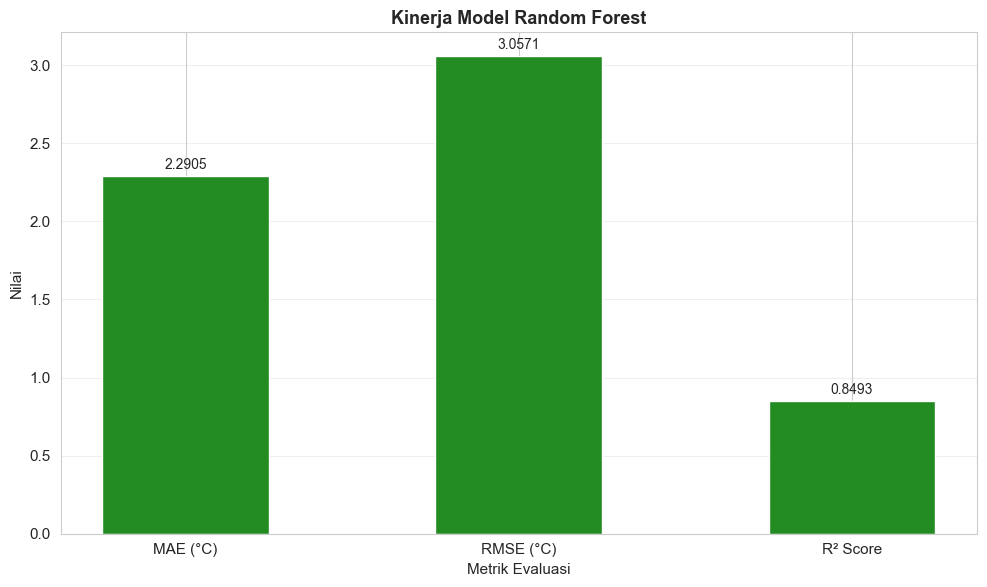

In [17]:
# ============================================
# VISUALISASI METRIK EVALUASI - RANDOM FOREST
# ============================================

metrics = ['MAE (°C)', 'RMSE (°C)', 'R² Score']
rf_values = [mae_rf, rmse_rf, r2_rf]

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, rf_values, width=0.5, color='forestgreen')

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai')
ax.set_title('Kinerja Model Random Forest', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.grid(True, alpha=0.3, axis='y')

# Menambahkan nilai di atas batang
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

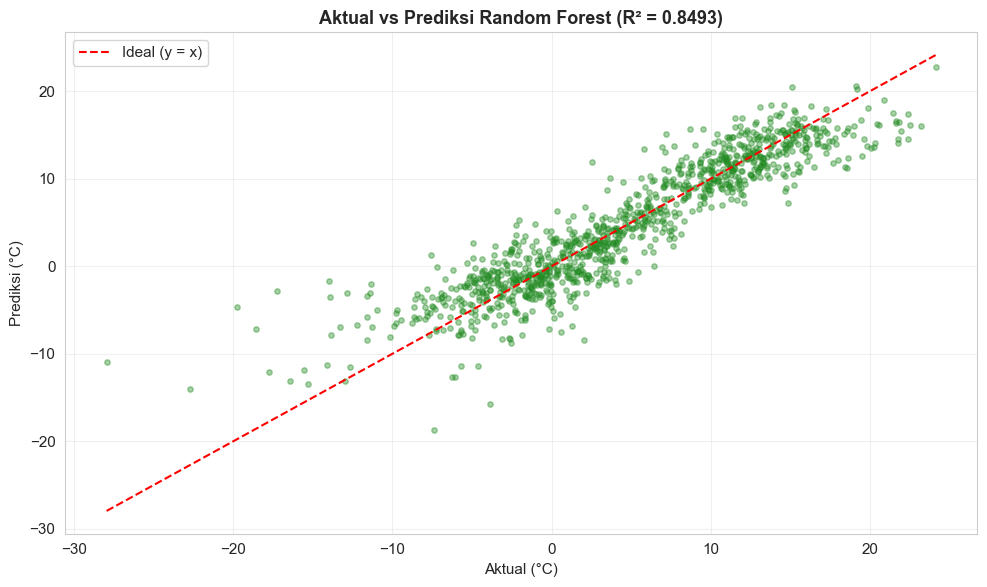

In [18]:
# ============================================
# VISUALISASI AKTUAL VS PREDIKSI - RANDOM FOREST
# ============================================

plt.figure(figsize=(10, 6))

# Scatter plot aktual vs prediksi Random Forest
plt.scatter(y_test, y_pred_rf, 
            alpha=0.4, 
            color='forestgreen', 
            s=15)

# Garis ideal (y = x) - jika prediksi sama persis dengan aktual
min_v = min(y_test.min(), y_pred_rf.min())
max_v = max(y_test.max(), y_pred_rf.max())
plt.plot([min_v, max_v], [min_v, max_v], 
         'r--', linewidth=1.5, 
         label='Ideal (y = x)')

plt.title(f'Aktual vs Prediksi Random Forest (R² = {r2_rf:.4f})', 
          fontweight='bold', fontsize=13)
plt.xlabel('Aktual (°C)')
plt.ylabel('Prediksi (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()